# XGBoost Forecast for ipi_abs_index_sa
This notebook builds an XGBoost model to forecast ipi_abs_index_sa


## 1 — Import Required Libraries

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
import joblib

print('All libraries loaded successfully.')


All libraries loaded successfully.


## 2 — Configuration

In [ ]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))

CANDIDATE_PATHS = [
    os.path.join(NOTEBOOK_DIR, 'combined_air_electricity_ipi_cleaned.csv'),
    os.path.join(NOTEBOOK_DIR, '..', 'COS40007DataCleaning', 'combined_air_electricity_ipi_cleaned.csv'),
    os.path.join(NOTEBOOK_DIR, '..', 'public', 'data', 'combined_air_electricity_ipi_cleaned.csv'),
]
FILE_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if FILE_PATH is None:
    raise FileNotFoundError('Could not find combined_air_electricity_ipi_cleaned.csv')

TARGET_COL  = 'ipi_abs_index_sa'
TEST_SIZE   = 12
LOOKBACK    = 3
SEED        = 42

BEST_PARAMS = {
    'n_estimators'    : 500,
    'max_depth'       : 4,
    'learning_rate'   : 0.1,
    'reg_lambda'      : 0.01,
    'min_child_weight': 3,
    'subsample'       : 0.9,
    'colsample_bytree': 0.8,
    'objective'       : 'reg:squarederror',
    'random_state'    : 42,
    'verbosity'       : 0,
}


## 3 — Load CSV Dataset

In [17]:
df = pd.read_csv(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Forecast target: {TARGET_COL}')
print(f'Dataset shape before outlier removal: {df.shape}')
print('First 5 rows:')
print(df[['date', TARGET_COL]].head())
print('Last 5 rows:')
print(df[['date', TARGET_COL]].tail())


Forecast target: ipi_abs_index_sa
Dataset shape before outlier removal: (60, 20)
First 5 rows:
        date  ipi_abs_index_sa
0 2018-01-01           109.866
1 2018-02-01           110.830
2 2018-03-01           111.090
3 2018-04-01           113.036
4 2018-05-01           112.183
Last 5 rows:
         date  ipi_abs_index_sa
55 2022-08-01           129.242
56 2022-09-01           129.370
57 2022-10-01           126.123
58 2022-11-01           127.845
59 2022-12-01           126.652


## 4 — Outlier Smoothing (Z-Score, threshold = 3)

In [18]:
z_scores = np.abs(zscore(df[TARGET_COL]))
df[TARGET_COL] = np.where(z_scores > 3, np.nan, df[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].interpolate()

print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Total months after outlier smoothing: {len(df)}')
print(f'Outliers smoothed: {(z_scores > 3).sum()}')


Date range: 2018-01-01 00:00:00 to 2022-12-01 00:00:00
Total months after outlier smoothing: 60
Outliers smoothed: 1


## 5 — Log Transformation & ADF Stationarity Test

Result for ipi_abs_index_sa: Not stationary → first-order differencing applied.


In [19]:
df.set_index('date', inplace=True)
df[f'log_{TARGET_COL}'] = np.log(df[TARGET_COL])
log_series = df[f'log_{TARGET_COL}']
print(f'Log transformation applied to {TARGET_COL}.')

def run_adf_test(series, alpha=0.05):
    result = adfuller(series, autolag='AIC')
    print(f'ADF statistic: {result[0]:.4f}, p-value: {result[1]:.4f}, '
          f'usedlag: {result[2]}, nobs: {result[3]}')
    return result[1] <= alpha

print('ADF test on log-transformed series (informational):')
run_adf_test(log_series)

difference_order = 1
processed_series = log_series.diff().dropna()
print('\nApplied first-order differencing (difference_order=1).')
print('ADF test after differencing (should be stationary):')
run_adf_test(processed_series)
print(f'Final processed data length: {len(processed_series)}')
data = processed_series.values.reshape(-1, 1)
print(f'Data shape: {data.shape}')


Log transformation applied to ipi_abs_index_sa.
ADF test on log-transformed series (informational):
ADF statistic: -2.4970, p-value: 0.1162, usedlag: 0, nobs: 59

Applied first-order differencing (difference_order=1).
ADF test after differencing (should be stationary):
ADF statistic: -6.8896, p-value: 0.0000, usedlag: 2, nobs: 56
Final processed data length: 59
Data shape: (59, 1)


## 6 — Split Data into Train and Test (Last 12 Months)


In [20]:
train_data = data[:-TEST_SIZE]
test_data  = data[-TEST_SIZE:]

print(f'Train data shape: {train_data.shape}')
print(f'Test  data shape: {test_data.shape}')
print(f'Train range: {len(train_data)} months')
print(f'Test  range: {len(test_data)} months')


Train data shape: (47, 1)
Test  data shape: (12, 1)
Train range: 47 months
Test  range: 12 months


## 7 — Scale Data with MinMaxScaler After Split
MinMaxScaler is fitted on the training data only, then applied to the
test set(no leakage).


In [21]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print(f'Scaled train shape: {train_scaled.shape}')
print(f'Scaled test  shape: {test_scaled.shape}')
print(f'Scaler min: {scaler.data_min_[0]:.4f}, max: {scaler.data_max_[0]:.4f}')


Scaled train shape: (47, 1)
Scaled test  shape: (12, 1)
Scaler min: -0.0896, max: 0.2130


## 8 — Build Lag Features (Lookback = 3)

The test set is extended with the last lookback training rows 
so all 12 test predictions are available without losing any warm-up rows.

| Feature | Description |
|---|---|
| `lag1` – `lag3` | Past 3 scaled values (autoregressive) |
| `roll_mean3` | 3-step rolling mean (local trend) |
| `roll_std3` | 3-step rolling std (volatility) |
| `month` | Calendar month (seasonality) |


In [22]:
def create_features(scaled_data, dates_index, lookback):
    rows = []
    for i in range(lookback, len(scaled_data)):
        r = {}
        for lag in range(1, lookback + 1):
            r[f'lag{lag}'] = scaled_data[i - lag, 0]
        r['roll_mean3'] = np.mean(scaled_data[max(0, i-3):i, 0])
        r['roll_std3']  = np.std(scaled_data[max(0, i-3):i, 0])
        r['roll_mean6'] = np.mean(scaled_data[max(0, i-6):i, 0])
        r['month']      = dates_index[i].month
        rows.append(r)
    feat_df = pd.DataFrame(rows, index=dates_index[lookback:])
    target  = scaled_data[lookback:, 0]
    return feat_df, target

test_extended = np.vstack((train_scaled[-LOOKBACK:], test_scaled))

X_train_feat, y_train_feat = create_features(
    train_scaled, processed_series.index[:len(train_data)], LOOKBACK
)

test_ext_dates = processed_series.index[len(train_data) - LOOKBACK:]
X_test_feat, y_test_feat = create_features(test_extended, test_ext_dates, LOOKBACK)

FEATURE_COLS = X_train_feat.columns.tolist()

print(f'X_train shape: {X_train_feat.shape}')
print(f'X_test  shape: {X_test_feat.shape}')
print(f'Features: {FEATURE_COLS}')


X_train shape: (44, 7)
X_test  shape: (12, 7)
Features: ['lag1', 'lag2', 'lag3', 'roll_mean3', 'roll_std3', 'roll_mean6', 'month']


## 9 — Walk-Forward Validation


In [23]:
def walk_forward_validation_xgb(train_scaled, dates_index, lookback=3,
                                  val_size=4, n_splits=3, initial_train_size=20):
    total_len = len(train_scaled)
    max_splits = (total_len - lookback - val_size) // val_size
    if max_splits < 1:
        raise ValueError('Not enough data for walk-forward validation.')
    n_splits = min(n_splits, max_splits)
    metrics = []

    for split in range(n_splits):
        train_end = initial_train_size + (split + 1) * val_size
        val_start = train_end
        val_end   = val_start + val_size
        if val_end > total_len:
            print(f'Fold {split + 1}: not enough data, skipping.')
            break

        train_window = train_scaled[:train_end]
        val_window   = train_scaled[val_start:val_end]
        window_dates = dates_index[:val_end]

        # Train portion features
        Xtr_w, ytr_w = create_features(train_window, window_dates[:train_end], lookback)

        val_ext       = np.vstack((train_window[-lookback:], val_window))
        val_ext_dates = dates_index[train_end - lookback:val_end]
        Xva_w, yva_w  = create_features(val_ext, val_ext_dates, lookback)

        fold_model = XGBRegressor(**BEST_PARAMS)
        fold_model.fit(Xtr_w, ytr_w)

        yva_pred = fold_model.predict(Xva_w)
        mse  = mean_squared_error(yva_w, yva_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(yva_w, yva_pred)
        metrics.append((mse, rmse, r2))
        print(f'Fold {split+1}: train_end={train_end}, val_end={val_end}, '
              f'MSE={mse:.6f}, RMSE={rmse:.6f}, R²={r2:.6f}')

    return metrics

metrics = walk_forward_validation_xgb(
    train_scaled,
    processed_series.index[:len(train_data)],
    lookback=LOOKBACK, val_size=4, n_splits=3, initial_train_size=20
)

mse_vals  = [m[0] for m in metrics]
rmse_vals = [m[1] for m in metrics]
r2_vals   = [m[2] for m in metrics]

print('Walk-forward validation summary:')
print(f'Average MSE:  {np.mean(mse_vals):.6f}')
print(f'Average RMSE: {np.mean(rmse_vals):.6f}')
print(f'Average R²:   {np.mean(r2_vals):.6f}')


Fold 1: train_end=24, val_end=28, MSE=0.056081, RMSE=0.236814, R²=-1.000234
Fold 2: train_end=28, val_end=32, MSE=0.184979, RMSE=0.430092, R²=-0.817052
Fold 3: train_end=32, val_end=36, MSE=0.025433, RMSE=0.159478, R²=-5.489474
Walk-forward validation summary:
Average MSE:  0.088831
Average RMSE: 0.275462
Average R²:   -2.435587


## 10 — Train Final XGBoost Model on Full Training Set

In [24]:
print('Training final XGBoost model on the full training set...')

model = XGBRegressor(**BEST_PARAMS)
model.fit(X_train_feat, y_train_feat,
          eval_set=[(X_train_feat, y_train_feat), (X_test_feat, y_test_feat)],
          verbose=False)

print('Training completed!')


Training final XGBoost model on the full training set...
Training completed!


## 11 — Evaluate with MSE, RMSE, and R² (Scaled Data)


In [25]:
y_pred_scaled = model.predict(X_test_feat)

mse_scaled  = mean_squared_error(y_test_feat, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled   = r2_score(y_test_feat, y_pred_scaled)

print('=== Metrics on Scaled Data ===')
print(f'MSE (scaled):  {mse_scaled:.6f}')
print(f'RMSE (scaled): {rmse_scaled:.6f}')
print(f'R² (scaled):   {r2_scaled:.6f}')


=== Metrics on Scaled Data ===
MSE (scaled):  0.003792
RMSE (scaled): 0.061578
R² (scaled):   0.254829


## 12 — Inverse Scale Predictions


In [26]:
y_pred_diff_vals = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_diff_vals = scaler.inverse_transform(y_test_feat.reshape(-1, 1))

if difference_order == 0:
    y_pred_log_values = y_pred_diff_vals
    y_test_log_values = y_test_diff_vals

elif difference_order == 1:
    prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff_vals + prev1
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

else:  
    prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    prev2 = log_series.iloc[-TEST_SIZE - 2:-2].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff_vals + 2 * prev1 - prev2
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

y_pred_original = np.exp(y_pred_log_values)
y_test_original = np.exp(y_test_log_values)

assert y_pred_original.shape == y_test_original.shape, \
    f'Shape mismatch! Preds: {y_pred_original.shape}, Actuals: {y_test_original.shape}'
assert len(y_pred_original) == TEST_SIZE, \
    f'Expected {TEST_SIZE} predictions, got {len(y_pred_original)}'

mse_original  = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original   = r2_score(y_test_original, y_pred_original)

print('=== Metrics on Original Scale ===')
print(f'MSE  (original): {mse_original:.20f}')
print(f'RMSE (original): {rmse_original:.20f}')
print(f'R²   (original): {r2_original:.6f}')


=== Metrics on Original Scale ===
MSE  (original): 5.55468491619001536463
RMSE (original): 2.35683790621884226013
R²   (original): 0.159572


## 13 — Plot Prediction vs Actual
Single figure is displayed **inline in the notebook only** (not saved as PNG).


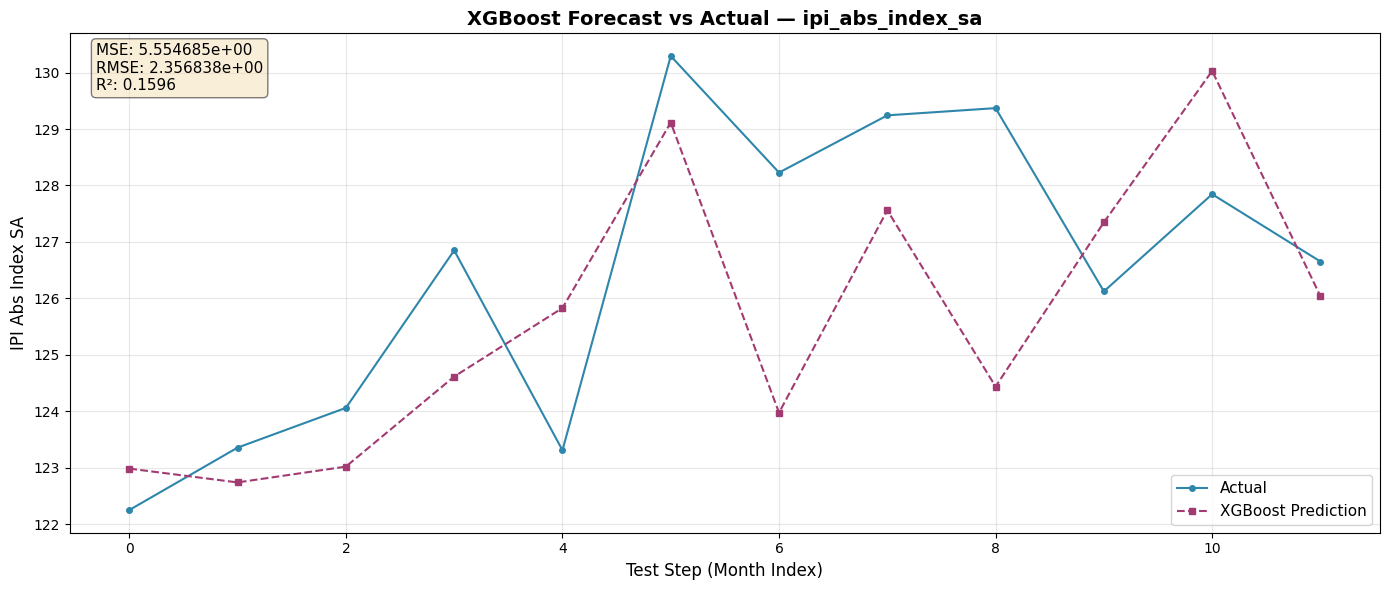


✓ Forecast completed successfully!
Figure is displayed inline in the notebook only (no PNG file saved to disk).


In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_test_original.flatten(), marker='o', linestyle='-',
        linewidth=1.5, label='Actual', color='#2E86AB', markersize=4)
ax.plot(y_pred_original.flatten(), marker='s', linestyle='--',
        linewidth=1.5, label='XGBoost Prediction', color='#A23B72', markersize=4)

ax.set_title(f'XGBoost Forecast vs Actual — {TARGET_COL}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Test Step (Month Index)', fontsize=12)
ax.set_ylabel('IPI Abs Index SA', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

metrics_text = (f'MSE: {mse_original:.6e}\n'
                f'RMSE: {rmse_original:.6e}\n'
                f'R²: {r2_original:.4f}')
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f'\n✓ Forecast completed successfully!')
print('Figure is displayed inline in the notebook only (no PNG file saved to disk).')


## 14 — Save Model
Saves in two formats matching project conventions:
- xgboost_model_forecast_ipi_abs_index_sa.json XGBoost native format (reload with model.load_model())
- xgboost_model_forecast_ipi_abs_index_sa.pkl — joblib bundle with model + scaler + metadata


In [28]:
# XGBoost native format
model.save_model('xgboost_model_forecast_ipi_abs_index_sa.json')

# Joblib bundle (.pkl)
bundle = {
    'model'           : model,
    'scaler'          : scaler,
    'feature_cols'    : FEATURE_COLS,
    'lookback'        : LOOKBACK,
    'test_size'       : TEST_SIZE,
    'difference_order': difference_order,
    'best_params'     : BEST_PARAMS,
    'mse_scaled'      : float(mse_scaled),
    'rmse_scaled'     : float(rmse_scaled),
    'r2_scaled'       : float(r2_scaled),
    'mse_original'    : float(mse_original),
    'rmse_original'   : float(rmse_original),
    'r2_original'     : float(r2_original),
}
joblib.dump(bundle, 'xgboost_model_forecast_ipi_abs_index_sa.pkl')

print('Model saved (XGBoost native) : xgboost_model_forecast_ipi_abs_index_sa.json')
print('Model saved (joblib bundle)  : xgboost_model_forecast_ipi_abs_index_sa.pkl')
print(f'Bundle keys: {list(bundle.keys())}')
print()
print('To reload:')
print('  bundle = joblib.load("xgboost_model_forecast_ipi_abs_index_sa.pkl")')
print('  model  = bundle["model"]')
print('  scaler = bundle["scaler"]')


Model saved (XGBoost native) : xgboost_model_forecast_ipi_abs_index_sa.json
Model saved (joblib bundle)  : xgboost_model_forecast_ipi_abs_index_sa.pkl
Bundle keys: ['model', 'scaler', 'feature_cols', 'lookback', 'test_size', 'difference_order', 'best_params', 'mse_scaled', 'rmse_scaled', 'r2_scaled', 'mse_original', 'rmse_original', 'r2_original']

To reload:
  bundle = joblib.load("xgboost_model_forecast_ipi_abs_index_sa.pkl")
  model  = bundle["model"]
  scaler = bundle["scaler"]
